# Assignment 8
## Topic: KNN Algorithm

### Question 1
Load the Iris dataset from sklearn.datasets. Display the first 10 rows and identify the features and target variable.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display first 10 rows
print(df.head(10).to_string())

# Identify features and target
print("\nFeatures:", list(iris.feature_names))
print("Target variable: target (0=setosa, 1=versicolor, 2=virginica)")

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target species
0                5.1               3.5                1.4               0.2       0  setosa
1                4.9               3.0                1.4               0.2       0  setosa
2                4.7               3.2                1.3               0.2       0  setosa
3                4.6               3.1                1.5               0.2       0  setosa
4                5.0               3.6                1.4               0.2       0  setosa
5                5.4               3.9                1.7               0.4       0  setosa
6                4.6               3.4                1.4               0.3       0  setosa
7                5.0               3.4                1.5               0.2       0  setosa
8                4.4               2.9                1.4               0.2       0  setosa
9                4.9               3.1                1.5               0.1     

### Question 2
Using pandas and matplotlib, visualize the relationship between the features. Create scatter plots for pairs of features and highlight the classes using different colors.

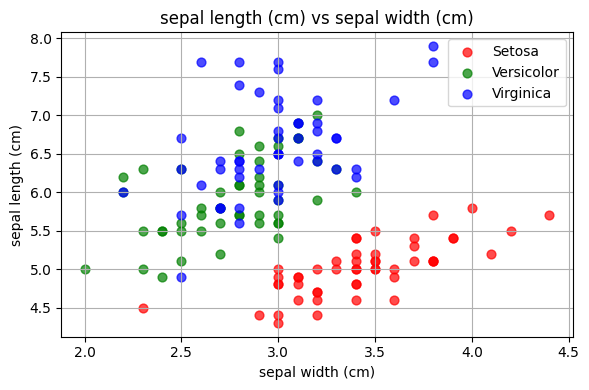

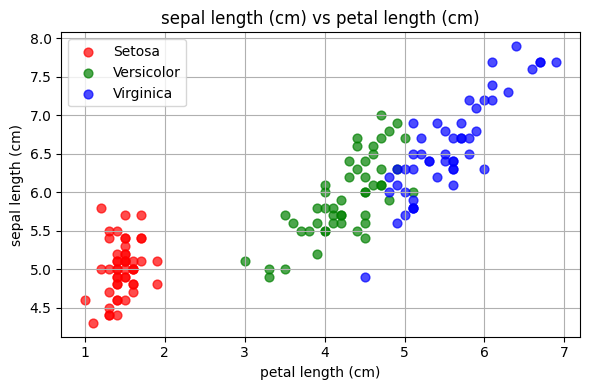

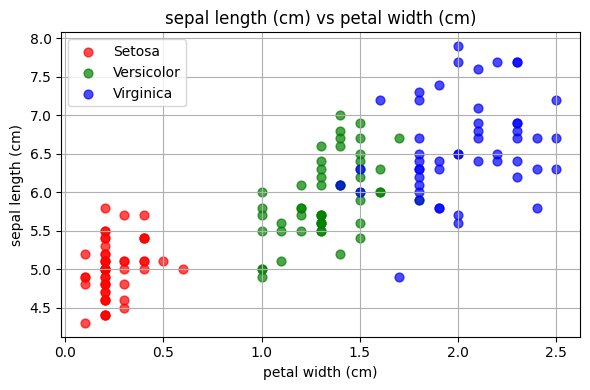

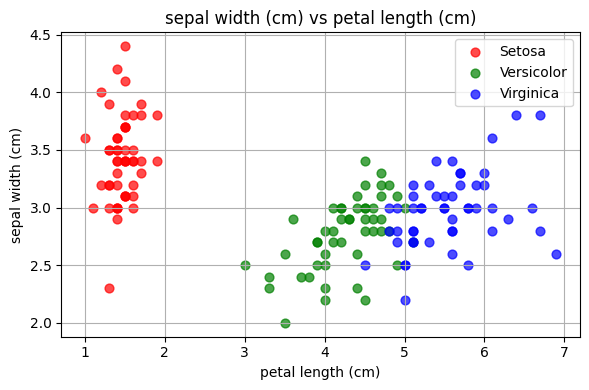

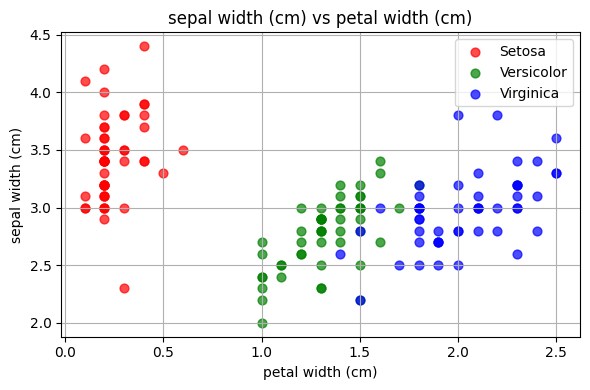

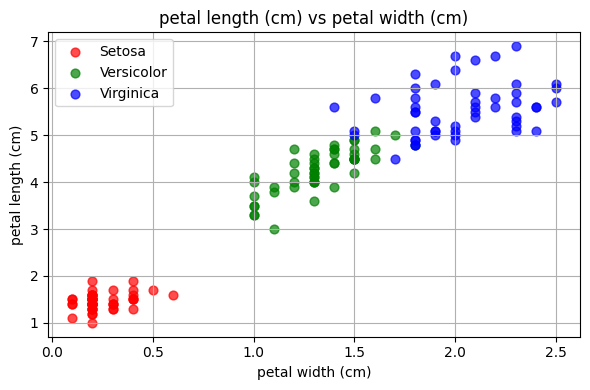

In [2]:
import matplotlib.pyplot as plt
from itertools import combinations

# Define colors and labels for each class
colors = {0: 'red', 1: 'green', 2: 'blue'}
labels = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
features = iris.feature_names

# Generate all unique pairs of features
pairs = list(combinations(range(4), 2))

for (i, j) in pairs:
    plt.figure(figsize=(6, 4))
    for cls in [0, 1, 2]:
        subset = df[df['target'] == cls]
        plt.scatter(subset[features[j]], subset[features[i]], c=colors[cls],
                    label=labels[cls], alpha=0.7, s=40)
    plt.xlabel(features[j])
    plt.ylabel(features[i])
    plt.title(f'{features[i]} vs {features[j]}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Question 3
Split the dataset into training (70%) and testing (30%) sets. Build a KNN classifier with K = 3 using sklearn. Train the model and print the predicted classes for the test set.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

print("----- KNN Classifier (K=3) -----")

# Prepare features and target
X = iris.data
y = iris.target

# Split into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nTraining set size:", len(X_train))
print("Testing set size:", len(X_test))

# Build KNN classifier with K=3
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

print("\nKNN Model Trained Successfully.")

# Predict classes for the test set
y_pred = knn.predict(X_test)
print("\nPredicted classes for the test set:")
print(y_pred)

----- KNN Classifier (K=3) -----

Training set size: 105
Testing set size: 45

KNN Model Trained Successfully.

Predicted classes for the test set:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


### Question 4
Evaluate the KNN classifier by calculating: Accuracy, Precision, Recall, and F1-score for each class.

In [4]:
from sklearn.metrics import accuracy_score, classification_report

print("----- Model Evaluation -----")

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)

# Classification Report: Precision, Recall, F1-score per class
print("\nClassification Report (Precision, Recall, F1-score per class):")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

----- Model Evaluation -----

Accuracy: 1.0

Classification Report (Precision, Recall, F1-score per class):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### Question 5
Test the KNN classifier with different values of K (1, 3, 5, 7, 9). Plot accuracy vs K. Determine the optimal value of K for this dataset.

----- Accuracy vs K -----

K=1: Accuracy = 1.0000

K=3: Accuracy = 1.0000

K=5: Accuracy = 1.0000

K=7: Accuracy = 1.0000

K=9: Accuracy = 1.0000

Optimal K: 1 (Accuracy: 1.0000)


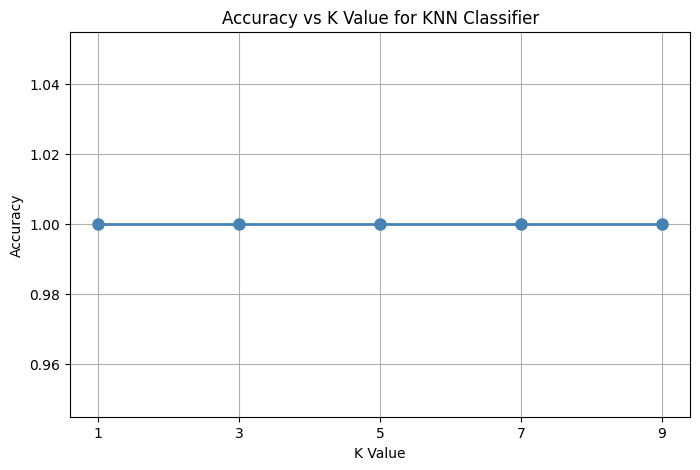

In [5]:
import matplotlib.pyplot as plt

print("----- Accuracy vs K -----")

# Test different values of K
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc_k = accuracy_score(y_test, knn_k.predict(X_test))
    accuracies.append(acc_k)
    print(f"\nK={k}: Accuracy = {acc_k:.4f}")

# Determine optimal K
optimal_k = k_values[accuracies.index(max(accuracies))]
print(f"\nOptimal K: {optimal_k} (Accuracy: {max(accuracies):.4f})")

# Plot Accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xticks(k_values)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value for KNN Classifier')
plt.grid(True)
plt.show()

### Question 6
Plot confusion matrix and ROC curve.

----- Confusion Matrix -----

 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


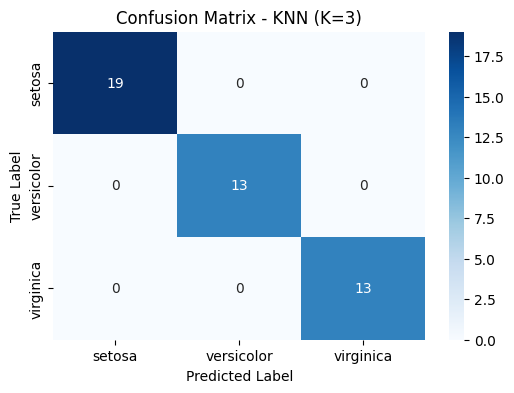


----- ROC Curve (One-vs-Rest) -----


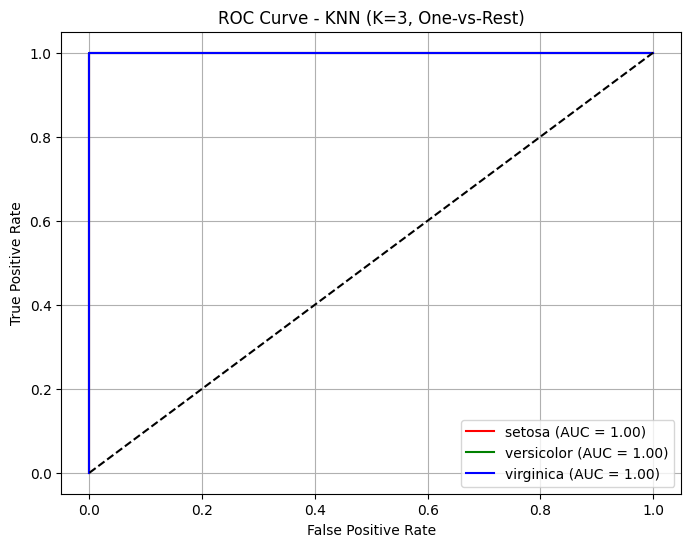

In [6]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# --- Confusion Matrix ---
print("----- Confusion Matrix -----")
cm = confusion_matrix(y_test, y_pred)
print("\n", cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - KNN (K=3)')
plt.show()

# --- ROC Curve (One-vs-Rest for multi-class) ---
print("\n----- ROC Curve (One-vs-Rest) -----")

# Binarize target for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob = knn.predict_proba(X_test)

colors = ['red', 'green', 'blue']
plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, color=colors[i], label=f'{iris.target_names[i]} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (K=3, One-vs-Rest)')
plt.legend()
plt.grid(True)
plt.show()